In [64]:
#solve the low thrust optimization problem as an qcqp 

#still developing
#we want to be able to match this solution with the polynomial optimization methods
using Pkg
Pkg.activate(".")

  Activating project at `~/Research/polynomial_opt`


In [65]:
using Test 
using LinearAlgebra
using SparseArrays
using Plots
using ForwardDiff
import lazy_nlp_qd 

In [66]:
#sizes of all the states 
#make sure to start the state vector with a 1 

#position at timestep k
nq = 3

#velocity at timestep k 
nv = 3

#position at timestep k+1
nq1 = 3

#velocity at timestep k+1 
nv1 = 3

#acceleration at timestep k 
na = 3

#slack for norm q 
nr = 1

#slack for norm q1
nr1 = 1

#slack for r^2 
ns = 1

#slack for r^3 
nw = 1

#control variable 
nu = 3

3

In [67]:
#gravitational parameter for the Earth 
μ = 3.986004418e5 #km3/s2

398600.4418

In [68]:
#iss initial conditions
r0 = [6791.0; 0; 0] #km
v0 = [0; cosd(51.5)*7.66; sind(51.5)*7.66] #km/s
x_initial_0 = [r0; v0]

6-element Vector{Float64}:
 6791.0
    0.0
    0.0
    0.0
    4.768462116644166
    5.994778481489491

In [69]:
#finding the period
r_initial = norm(r0)

#for 1 rev
iss_period = 2*pi*sqrt(r_initial^3/μ)

5569.440597283014

In [70]:
#working for 1 rev ...
#revs = 1

#around 8 min solve time... (working)
#revs = 10

#revs for polynomial opt example (working) 4 second solve time 
revs = 5

#period 
period = revs*iss_period 

27847.202986415068

In [71]:
#working with 10 rev horizon 
#knot_pts = 30

#course discretization that we try out in the polynomial opt example
#working with 5 rev horizon
knot_pts = 10

#number of knot points  
N=knot_pts*revs

50

In [72]:
#define a timestep
#in seconds 
h = period/(N-1) 

568.3102650288789

In [73]:
function two_body_dynamics(x)

    q = x[1:3]
    v = x[4:6]

    a = zeros(eltype(x), size(x))

    r = norm(q)
    
    a[1:3] = v

    a[4:6] = (-μ/r^3)*q

    return a

end

two_body_dynamics (generic function with 1 method)

In [74]:
#semi implicit euler 
function symplectic_euler(x)

    #the q and the v are already scaled 
    q = x[1:3]
    v = x[4:6]

    #next timestep
    xnext = zeros(6)

    #ak = two_body_dynamics(x)[4:6]
    ak = (-μ/(norm(q)^3))*q
    #ak = (-μ_scaled/(norm(q)^3))*q


    #explicit euler on the velocities
    #vk1
    xnext[4:6] = v + h*ak

    #implicit euler on the positions
    #qk1
    xnext[1:3] = q + h*xnext[4:6]

    return xnext 

end

symplectic_euler (generic function with 1 method)

In [75]:
#integrate the orbit with symplectic euler to see if it closes

xtraj = zeros(6, N)

xtraj[:,1] = x_initial_0


6-element Vector{Float64}:
 6791.0
    0.0
    0.0
    0.0
    4.768462116644166
    5.994778481489491

In [76]:
#integrate using symplectic Euler to generate an initial guess
for i=1:N-1

    xtraj[:,i+1] = symplectic_euler(xtraj[:,i])

end


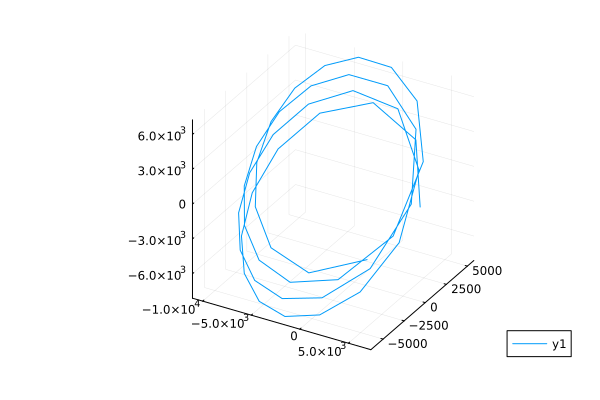

In [77]:
plot(xtraj[1,:], xtraj[2,:], xtraj[3,:])

In [78]:
#going to scale position by semi major axis length 
position_scale = r_initial 

#scaled to make the period 1 
#time_scale = iss_period 
#works with 1
#thrust_limit_kN = 0.000432

#this works with 29% sub opt gap  (block structure)
#0.6% opt gap with MD structure 
#this is working...
#thrust_limit_kN = 0.00002

#2 Newtons 
#thrust_limit_kN = 0.002

#2 milliNewton
#thrust_limit_kN = 0.000002

thrust_limit_kN = 20e-9

#currently in the testing code
#this works 
#thrust_limit_kN = 2e-5

#scale to make the minimum control 1
#time_scale = sqrt(position_scale/thrust_limit_kN)

#scaled to make the period 1
time_scale = period 

velocity_scale = position_scale/time_scale

acceleration_scale = position_scale/time_scale^2

μ_scaled = μ/(position_scale^3/time_scale^2)

h_scaled = h/time_scale

u_max_bound = thrust_limit_kN/acceleration_scale 

0.002283807139350918

In [79]:
q_k = [1,2,3]

v_k = [4,5,6]

q_k1 = [1,2,3]

v_k1 = [4,5,6]

a_k = [1,2,3]

r_k = 10

r_k1 = 12

s_k = 13

w_k = 19

u_k = [2,3,4]


#create x as a vector of vectors/scalars
#indices work for this 
#x = [vector_1, vector_2, vector_3, scalar]

#check the indices code for this  
#x = [vector_1, vector_2, vector_3, vector_4, scalar]

x = [q_k, v_k, q_k1, v_k1, a_k, r_k, r_k1, s_k, w_k, u_k]


N_size = length(x)

#these are the sizes of each element
sizes = zeros(Int64, N_size)

for i=1:N_size

    sizes[i] = Int(length(x[i]))

end
#indices
#try to generate these automatically 
# v1_index = (2:4, 1)

# v2_index = (5:7, 1)

# v3_index = (8:10, 1)

# scalar_index = (11, 1)

# scalar_squared_index = (11,11)

In [80]:
flat_x = [1.0; Float64.(vcat(x...))] 

23-element Vector{Float64}:
  1.0
  1.0
  2.0
  3.0
  4.0
  5.0
  6.0
  1.0
  2.0
  3.0
  ⋮
  2.0
  3.0
 10.0
 12.0
 13.0
 19.0
  2.0
  3.0
  4.0

In [81]:
M = flat_x*flat_x' 

23×23 Matrix{Float64}:
  1.0   1.0   2.0   3.0   4.0   5.0    6.0  …   13.0   19.0   2.0   3.0   4.0
  1.0   1.0   2.0   3.0   4.0   5.0    6.0      13.0   19.0   2.0   3.0   4.0
  2.0   2.0   4.0   6.0   8.0  10.0   12.0      26.0   38.0   4.0   6.0   8.0
  3.0   3.0   6.0   9.0  12.0  15.0   18.0      39.0   57.0   6.0   9.0  12.0
  4.0   4.0   8.0  12.0  16.0  20.0   24.0      52.0   76.0   8.0  12.0  16.0
  5.0   5.0  10.0  15.0  20.0  25.0   30.0  …   65.0   95.0  10.0  15.0  20.0
  6.0   6.0  12.0  18.0  24.0  30.0   36.0      78.0  114.0  12.0  18.0  24.0
  1.0   1.0   2.0   3.0   4.0   5.0    6.0      13.0   19.0   2.0   3.0   4.0
  2.0   2.0   4.0   6.0   8.0  10.0   12.0      26.0   38.0   4.0   6.0   8.0
  3.0   3.0   6.0   9.0  12.0  15.0   18.0      39.0   57.0   6.0   9.0  12.0
  ⋮                             ⋮           ⋱                 ⋮          
  2.0   2.0   4.0   6.0   8.0  10.0   12.0      26.0   38.0   4.0   6.0   8.0
  3.0   3.0   6.0   9.0  12.0  15.0   18.0  …

In [19]:
sizes 

10-element Vector{Int64}:
 3
 3
 3
 3
 3
 1
 1
 1
 1
 3

In [20]:
#the first element can either be an Int64 or a range. same with the second element 
vectors = [Vector{Tuple{Union{Int64, UnitRange{Int64}}, Union{Int64, UnitRange{Int64}}}}() for _ in 1:N_size]

10-element Vector{Vector{Tuple{Union{UnitRange{Int64}, Int64}, Union{UnitRange{Int64}, Int64}}}}:
 []
 []
 []
 []
 []
 []
 []
 []
 []
 []

In [21]:
#there will be N+1 indices for each element in our state 

In [22]:
#this will only be for first order for now...

function generate_indices(x)

    #number of items in x 
    N = length(x)

    flat_x = [1.0; Float64.(vcat(x...))]

    indices = [Vector{Tuple{Union{Int64, UnitRange{Int64}}, Union{Int64, UnitRange{Int64}}}}() for _ in 1:N_size]
    #each element will have N+1 indices associated to it
    #the first is the index for the element itself
    # the second is the index for the element outer product with itself
    # the rest are the elements outer product with the other elements 
    
    #add the first index 
    push!(indices[1], (2:1+length(x[1]), 1:1))

    #initial index push 
    for i=2:N_size 

       push!(indices[i], (indices[i-1][1][1][end] .+ 1: indices[i-1][1][1][end] + length(x[i]), 1:1))

    end 

    for i=1:N_size
    
        for k=1:N_size

            push!(indices[i], (indices[i][k][1], indices[i][k][2][end] .+ 1: indices[i][k][2][end] + length(x[k])))

        end

    end

    return indices

end

generate_indices (generic function with 1 method)

In [23]:
#each set of indices is the vector itself, and then the vector outer product with itself and the other vectors are well
indices = generate_indices(x)

10-element Vector{Vector{Tuple{Union{UnitRange{Int64}, Int64}, Union{UnitRange{Int64}, Int64}}}}:
 [(2:4, 1:1), (2:4, 2:4), (2:4, 5:7), (2:4, 8:10), (2:4, 11:13), (2:4, 14:16), (2:4, 17:17), (2:4, 18:18), (2:4, 19:19), (2:4, 20:20), (2:4, 21:23)]
 [(5:7, 1:1), (5:7, 2:4), (5:7, 5:7), (5:7, 8:10), (5:7, 11:13), (5:7, 14:16), (5:7, 17:17), (5:7, 18:18), (5:7, 19:19), (5:7, 20:20), (5:7, 21:23)]
 [(8:10, 1:1), (8:10, 2:4), (8:10, 5:7), (8:10, 8:10), (8:10, 11:13), (8:10, 14:16), (8:10, 17:17), (8:10, 18:18), (8:10, 19:19), (8:10, 20:20), (8:10, 21:23)]
 [(11:13, 1:1), (11:13, 2:4), (11:13, 5:7), (11:13, 8:10), (11:13, 11:13), (11:13, 14:16), (11:13, 17:17), (11:13, 18:18), (11:13, 19:19), (11:13, 20:20), (11:13, 21:23)]
 [(14:16, 1:1), (14:16, 2:4), (14:16, 5:7), (14:16, 8:10), (14:16, 11:13), (14:16, 14:16), (14:16, 17:17), (14:16, 18:18), (14:16, 19:19), (14:16, 20:20), (14:16, 21:23)]
 [(17:17, 1:1), (17:17, 2:4), (17:17, 5:7), (17:17, 8:10), (17:17, 11:13), (17:17, 14:16), (17:17, 17:

In [24]:
#come up with the A matrices to construct the quadratic constraints 

#this is the A matrix for the quadratic cost on r_k1

A_cost =  zeros(size(M))
A_cost[indices[7][1]...] = [1] 

#checked

1-element Vector{Int64}:
 1

In [25]:
#constraint on r^2 - q'q = 0 
#will only constrain r_k1 here because r_k is given by the initial condition
A_r_k1 = zeros(size(M))

#this indexes to get r^2
A_r_k1[indices[7][8]...] = [1]

#this indexes to get q'*q
A_r_k1[indices[3][2]...] = -Matrix(1.0*I, 3,3) 

#constraint checked

#will add the constraints on s and w once it is more than the one step problem 

3×3 Matrix{Float64}:
 -1.0  -0.0  -0.0
 -0.0  -1.0  -0.0
 -0.0  -0.0  -1.0

In [26]:
#this is a vector valued equation so there are three constraints attatched to this

#acceleration x-component constraint 
A_accel_dynamics_x = zeros(size(M))

A_accel_dynamics_x[indices[5][10][1][1], indices[5][10][2]] = [1] 

A_accel_dynamics_x[indices[1][1][1][1], indices[1][1][2]] = [μ_scaled] 

#acceleration y-component constraint 
A_accel_dynamics_y = zeros(size(M))

A_accel_dynamics_y[indices[5][10][1][2], indices[5][10][2]] = [1] 

A_accel_dynamics_y[indices[1][1][1][2], indices[1][1][2]] = [μ_scaled] 

#acceleration z-componenet constraint 
A_accel_dynamics_z = zeros(size(M))

A_accel_dynamics_z[indices[5][10][1][3], indices[5][10][2]] = [1] 

A_accel_dynamics_z[indices[1][1][1][3], indices[1][1][2]] = [μ_scaled] 

#these are all checked and work

1-element Vector{Float64}:
 986.9604401089357

In [29]:
#set the first variable in the state flat_x equal to 1 
A_0 = zeros(size(M))

A_0[1,1] = 1 

#not checked, but should work....

1

In [30]:
indices 

10-element Vector{Vector{Tuple{Union{UnitRange{Int64}, Int64}, Union{UnitRange{Int64}, Int64}}}}:
 [(2:4, 1:1), (2:4, 2:4), (2:4, 5:7), (2:4, 8:10), (2:4, 11:13), (2:4, 14:16), (2:4, 17:17), (2:4, 18:18), (2:4, 19:19), (2:4, 20:20), (2:4, 21:23)]
 [(5:7, 1:1), (5:7, 2:4), (5:7, 5:7), (5:7, 8:10), (5:7, 11:13), (5:7, 14:16), (5:7, 17:17), (5:7, 18:18), (5:7, 19:19), (5:7, 20:20), (5:7, 21:23)]
 [(8:10, 1:1), (8:10, 2:4), (8:10, 5:7), (8:10, 8:10), (8:10, 11:13), (8:10, 14:16), (8:10, 17:17), (8:10, 18:18), (8:10, 19:19), (8:10, 20:20), (8:10, 21:23)]
 [(11:13, 1:1), (11:13, 2:4), (11:13, 5:7), (11:13, 8:10), (11:13, 11:13), (11:13, 14:16), (11:13, 17:17), (11:13, 18:18), (11:13, 19:19), (11:13, 20:20), (11:13, 21:23)]
 [(14:16, 1:1), (14:16, 2:4), (14:16, 5:7), (14:16, 8:10), (14:16, 11:13), (14:16, 14:16), (14:16, 17:17), (14:16, 18:18), (14:16, 19:19), (14:16, 20:20), (14:16, 21:23)]
 [(17:17, 1:1), (17:17, 2:4), (17:17, 5:7), (17:17, 8:10), (17:17, 11:13), (17:17, 14:16), (17:17, 17:

In [31]:
#discrete dynamics for position (3 constraints)
#symplectic euler dynamics 
#first number is the variable we care about, next is which index. (1 is itself), then the next is which component in that vector 

#x position constraint 
A_position_dynamics_x = zeros(size(M))

A_position_dynamics_x[indices[3][1][1][1], indices[3][1][2]] = [1]
A_position_dynamics_x[indices[1][1][1][1], indices[1][1][2]] = [-1]
A_position_dynamics_x[indices[4][1][1][1], indices[4][1][2]] = [-h_scaled]

#y position constraint 
A_position_dynamics_y = zeros(size(M))

A_position_dynamics_y[indices[3][1][1][2], indices[3][1][2]] = [1]
A_position_dynamics_y[indices[1][1][1][2], indices[1][1][2]] = [-1]
A_position_dynamics_y[indices[4][1][1][2], indices[4][1][2]] = [-h_scaled]

#z poisition constraint 
A_position_dynamics_z = zeros(size(M))

A_position_dynamics_z[indices[3][1][1][3], indices[3][1][2]] = [1]
A_position_dynamics_z[indices[1][1][1][3], indices[1][1][2]] = [-1]
A_position_dynamics_z[indices[4][1][1][3], indices[4][1][2]] = [-h_scaled]

#checked

1-element Vector{Float64}:
 -0.02040816326530612

In [32]:
#discrete dynamics for velocity (3 constraints)
A_velocity_dynamics_x = zeros(size(M))
A_velocity_dynamics_x[indices[4][1][1][1], indices[4][1][2]] = [1]
A_velocity_dynamics_x[indices[2][1][1][1], indices[2][1][2]] = [-1]
A_velocity_dynamics_x[indices[5][1][1][1], indices[5][1][2]] = [-h_scaled]
A_velocity_dynamics_x[indices[10][1][1][1], indices[10][1][2]] = [-h_scaled]

A_velocity_dynamics_y = zeros(size(M))
A_velocity_dynamics_y[indices[4][1][1][2], indices[4][1][2]] = [1]
A_velocity_dynamics_y[indices[2][1][1][2], indices[2][1][2]] = [-1]
A_velocity_dynamics_y[indices[5][1][1][2], indices[5][1][2]] = [-h_scaled]
A_velocity_dynamics_y[indices[10][1][1][2], indices[10][1][2]] = [-h_scaled]

A_velocity_dynamics_z = zeros(size(M))
A_velocity_dynamics_z[indices[4][1][1][3], indices[4][1][2]] = [1]
A_velocity_dynamics_z[indices[2][1][1][3], indices[2][1][2]] = [-1]
A_velocity_dynamics_z[indices[5][1][1][3], indices[5][1][2]] = [-h_scaled]
A_velocity_dynamics_z[indices[10][1][1][3], indices[10][1][2]] = [-h_scaled]

#checked 

1-element Vector{Float64}:
 -0.02040816326530612

In [34]:
#bound constraint 

#this just picks out u 
#each of these matrix picks out a component of u 
A_control_x = zeros(size(M))
A_control_x[indices[10][1][1][1], indices[10][1][2]] = [1]


A_control_y = zeros(size(M))
A_control_y[indices[10][1][1][2], indices[10][1][2]] = [1]

A_control_z = zeros(size(M))
A_control_z[indices[10][1][1][3], indices[10][1][2]] = [1]

1-element Vector{Int64}:
 1

In [44]:
indices[1][1][2] 

1:1

In [45]:
indices 

10-element Vector{Vector{Tuple{Union{UnitRange{Int64}, Int64}, Union{UnitRange{Int64}, Int64}}}}:
 [(2:4, 1:1), (2:4, 2:4), (2:4, 5:7), (2:4, 8:10), (2:4, 11:13), (2:4, 14:16), (2:4, 17:17), (2:4, 18:18), (2:4, 19:19), (2:4, 20:20), (2:4, 21:23)]
 [(5:7, 1:1), (5:7, 2:4), (5:7, 5:7), (5:7, 8:10), (5:7, 11:13), (5:7, 14:16), (5:7, 17:17), (5:7, 18:18), (5:7, 19:19), (5:7, 20:20), (5:7, 21:23)]
 [(8:10, 1:1), (8:10, 2:4), (8:10, 5:7), (8:10, 8:10), (8:10, 11:13), (8:10, 14:16), (8:10, 17:17), (8:10, 18:18), (8:10, 19:19), (8:10, 20:20), (8:10, 21:23)]
 [(11:13, 1:1), (11:13, 2:4), (11:13, 5:7), (11:13, 8:10), (11:13, 11:13), (11:13, 14:16), (11:13, 17:17), (11:13, 18:18), (11:13, 19:19), (11:13, 20:20), (11:13, 21:23)]
 [(14:16, 1:1), (14:16, 2:4), (14:16, 5:7), (14:16, 8:10), (14:16, 11:13), (14:16, 14:16), (14:16, 17:17), (14:16, 18:18), (14:16, 19:19), (14:16, 20:20), (14:16, 21:23)]
 [(17:17, 1:1), (17:17, 2:4), (17:17, 5:7), (17:17, 8:10), (17:17, 11:13), (17:17, 14:16), (17:17, 17:

In [48]:
indices[2][1][2]

1:1

In [50]:
indices[6][1]

(17:17, 1:1)

In [51]:
#initial state constraints

#A matrices to pick out state and slacks at first timestep 
A_position_x = zeros(size(M))
A_position_x[indices[1][1][1][1], indices[1][1][2] ] = [1]

A_position_y = zeros(size(M))
A_position_x[indices[1][1][1][2], indices[1][1][2] ] = [1]

A_position_z = zeros(size(M))
A_position_x[indices[1][1][1][3], indices[1][1][2] ] = [1]

A_velocity_x = zeros(size(M))
A_velocity_x[indices[2][1][1][1], indices[2][1][2] ] = [1]

A_velocity_y = zeros(size(M))
A_velocity_y[indices[2][1][1][2], indices[2][1][2] ] = [1]

A_velocity_z = zeros(size(M))
A_velocity_z[indices[2][1][1][3], indices[2][1][2] ] = [1]


#can also use this matrix that just picks out r for the lower bound on r 
A_initial_r = zeros(size(M))
A_initial_r[indices[6][1]...] = [1]

A_initial_s = zeros(size(M))
A_initial_s[indices[8][1]...] = [1]

A_initial_w = zeros(size(M))
A_initial_w[indices[9][1]...] = [1]


#matrix that picks out r1
A_r1 = zeros(size(M))
A_initial_w[indices[7][1]...] = [1]

1-element Vector{Int64}:
 1

In [52]:
#now that we have all the variables to construct the quadratic forms, add each constraint into IPOPT 

In [53]:
xtraj_scaled = [xtraj[1:3,:]./position_scale; xtraj[4:6,:]./velocity_scale]

6×50 Matrix{Float64}:
  1.0       0.588938   -0.189128  …   -0.82113   -0.173729   0.552223
  0.0       0.399053    0.549431      -0.507161  -0.593281  -0.411152
  0.0       0.501678    0.69073       -0.637589  -0.745857  -0.516889
  0.0     -20.142     -38.1252        21.0361    31.7226    35.5716
 19.5536   19.5536      7.36855      -10.8203    -4.21991    8.92434
 24.5822   24.5822      9.26353   …  -13.603     -5.30515   11.2194

In [54]:
#solve for a_traj_scaled
a_traj_scaled = zeros(3, N)


for i=1:N

    a_traj_scaled[:,i] = (-μ_scaled/(norm(xtraj_scaled[1:3, i])^3))*xtraj_scaled[1:3, i] 

end

In [55]:
a_traj_scaled 

3×50 Matrix{Float64}:
 -986.96  -881.175   253.815  …  521.799  523.642  188.601  -854.156
   -0.0   -597.066  -737.353     119.487  323.421  644.068   635.954
   -0.0   -750.615  -926.98      150.215  406.596  809.704   799.503

In [60]:
#to test out the qcqp, will only do 2 knot points 
N_test = 2

2

In [56]:
#updated for u and n variables in the ipopt projection problem

# function create_idx(nq, nv, na, nr, nu, N)

#     # This function creates some useful indexing tools for Z 
#     # q_i = Z[idx.q[i]]
#     # v_i = Z[idx.v[i]]
#     # a_i = Z[idx.a[i]]
#     # r_i = Z[idx.r[i]]
#     # u_i = Z[idx.u[i]]

#     #stacked up vector 
#     # z = [all_q, all_v, all_a, all_r, all_u]

#     #length of the entire stacked up vector 
#     nz = (N*nq) + (N*nv) + (N*na) + N*(nr) + ((N-1)*nu) 

#     q = [(i-1)*(nq) .+ (1:nq) for i=1:N]

#     v = [(i-1)*(nv) .+ (nq*N+1:nq*N+nv) for i=1:N]

#     a = [(i-1)*(na) .+ (nq*N+ nv*N + 1:nq*N+ nv*N+na) for i=1:N]

#     r = [(i-1)*(nr) .+ (nq*N+ nv*N + na*N +nr) for i=1:N]

#     u = [(i-1)*(nu) .+ (nq*N+ nv*N + na*N + nr*N+1:nq*N+ nv*N + na*N + nr*N +nu) for i=1:N-1]


#     #total number of dynamics constraints 
#     nd = (nq*(N-1)) + (nv*(N-1)) + (na*N)

#     #position integrator constraint 
#     cq = [(i-1)*(nq) .+ (1:nq) for i=1:N-1]

#     #velocity integrator constraint 
#     cv = [(i-1)*(nv) .+ ((nq*(N-1))+1:(nq*(N-1)) + nv) for i=1:N-1]

#     #acceleration constraint at each knot point 
#     ca = [(i-1)*(na) .+ ((nq*(N-1)) + (nv*(N-1))+1:(nq*(N-1)) +(nv*(N-1))+ na) for i=1:N]
    
#     return (q=q,v=v,N=N,a=a,r=r, u= u, cq = cq, cv = cv, ca = ca, nd= nd, nz= nz)

# end

create_idx (generic function with 1 method)

In [ ]:
#will hard code the state for now. eventually it would be coded by indices 
#state: Z = [qk, vk, qk1, vk1, ak, rk, rk1, sk, wk, uk]

#this is dimension 23

In [61]:
# idx_1 = create_idx(nq, nv, na, nr, nu, N_test) 

(q = UnitRange{Int64}[1:3, 4:6], v = UnitRange{Int64}[7:9, 10:12], N = 2, a = UnitRange{Int64}[13:15, 16:18], r = [19, 20], u = UnitRange{Int64}[21:23], cq = UnitRange{Int64}[1:3], cv = UnitRange{Int64}[4:6], ca = UnitRange{Int64}[7:9, 10:12], nd = 12, nz = 23)

In [ ]:
#dynamics equality constraints 

function dynamics_constraints(params, Z::Vector)

    c = zeros(eltype(Z), size(Z))

    #use the A matrices to formulate the quadratic constraints for this problem...

    #position dynamics constraint 
    
    c[1] = Z*



    #position constraints
    for i=1:(N-1)

        c[idx.cq[i]] = Z[idx.q[i+1]] - (Z[idx.q[i]] + h_scaled*Z[idx.v[i+1]])

    end

    #velocity constraints 
    for i=1:(N-1)

        c[idx.cv[i]] = Z[idx.v[i+1]] - (Z[idx.v[i]] + h_scaled*(Z[idx.a[i]] + Z[idx.u[i]]))

    end

    #acceleration constraint
    for i=1:N
        
        c[idx.ca[i]] = Z[idx.a[i]]*Z[idx.r[i]]^3 + μ_scaled*Z[idx.q[i]]

    end


    return c 

end

In [ ]:
function slack_constraint(params, Z::Vector)

    idx = params.idx

    c = zeros(eltype(Z), idx.N)

    #slack constraint at each knot point 

    for i=1:N 

        c[i] = Z[idx.r[i]]^2 - Z[idx.q[i]]'*Z[idx.q[i]]

    end

    return c 
    
end

In [ ]:
#works 

function cost(params, Z::Vector )


    idx, N = params.idx, params.N

    J = 0.0

    #minimize over the slack variable r 
    
    for i=1:N

        J += Z[idx.r[i]]

    end

    #add in the control regularizing term? 

    return J 

end

In [ ]:
function cost_gradient(params, Z)

    return [zeros(nq*N); zeros(nv*N); zeros(na*N); ones(nr*N); zeros(nu*(N-1))]
    
end

In [ ]:
# grad_test = zeros(387)

# cost_gradient!(params, grad_test, x_initial) 

# grad_test 

In [ ]:
#this is to test the cost gradient to make sure it is correct 

# cost_gradient = ForwardDiff.gradient(dZ -> cost(params, dZ), x_initial)  

In [ ]:
function equality_constraints(params, Z::Vector)

    #xic is the initial condition 

    idx, xic = params.idx, params.xic

    return [
    
    #initial position 
    Z[idx.q[1]] - xic[1:3]; 

    #initial velocity 
    Z[idx.v[1]] - xic[4:6]; 

    #dynamics constraints
    dynamics_constraints(params, Z);

    #slack constraint 
    slack_constraint(params, Z)

    ]

    
end

In [ ]:
#do not need this, can represent state bounds through xl and xu in the wrapper 

# function inequality_slack_constraint(params, Z::Vector)

#     #constraints are r>0.75 and r>0

#     idx, N = params.idx, params.N
 
#     c1 = zeros(eltype(Z), N)

#     c2 = zeros(eltype(Z), N)

#     c = zeros(eltype(Z), 2*N)

#     #r>0.75 constraint 
#     for i=1:N

#         c1[i] = 0.75 - Z[idx.r[i]]

#     end

#     #r>0 constraint
#     for i=1:N

#         c2[i] = -Z[idx.r[i]]

#     end

#     c[1:N] = c1
#     c[N+1:2*N] = c2

#     return c 

# end

In [ ]:
#no inequality constraints other than state bounds 
# function inequality_constraints(params, Z)

#     return inequality_slack_constraint(params, Z)

# end

In [ ]:
#in place function for the constraints 
#seems good 
function all_constraints(params, Z)

    return equality_constraints(params, Z)

end

In [ ]:
function con(params, Z)

    return equality_constraints(params, Z)
    
end 

In [ ]:
#seems good
function all_constraints_jacobian(params, Z)

    return ForwardDiff.jacobian(dZ -> con(params, dZ), Z)

end 

In [ ]:
#we have no inequality constraints 
c_l = zeros(0)

c_u = zeros(0)

In [ ]:
x_l = -Inf*ones(idx_1.nz)
x_u = Inf*ones(idx_1.nz)

In [ ]:
#bound the states 

for i = 1:N

    #lower bounds 
    x_l[idx_1.q[i]] .= -2.0
    x_l[idx_1.v[i]] .= -200.0
    x_l[idx_1.r[i]] = 0.75

    #upper bounds
    x_u[idx_1.q[i]] .= 2.0
    x_u[idx_1.v[i]] .= 200.0
    x_u[idx_1.r[i]] = 2.0

end



#bound the controls 
#in scaled units 
for i=1:N-1

    x_l[idx_1.u[i]] .= -u_max_bound

    x_u[idx_1.u[i]] .= u_max_bound

end

In [ ]:
#get the initial guess

x_initial = zeros(idx_1.nz)


#fill out the states

for i=1:N

    x_initial[idx_1.q[i]] = xtraj_scaled[1:3, i]
    x_initial[idx_1.v[i]] = xtraj_scaled[4:6, i]
    x_initial[idx_1.a[i]] = a_traj_scaled[:,i] 
    x_initial[idx_1.r[i]] = norm(xtraj_scaled[1:3, i])

end

#fill out the controls
#zeros for now 
for i=1:N-1

    x_initial[idx_1.u[i]] = zeros(3)

end

In [ ]:
x_initial 

In [ ]:
#define the parameters 
params = (N = N, idx = idx_1, xic = xtraj_scaled[:, 1])

In [ ]:
function inequality_constraints(params, Z)

    return zeros(eltype(Z), 0)

end

In [ ]:
diff_type = :auto 

In [ ]:
    """ we are solving the following problem:
    
        minimize_x        cost(x)
        subject to        c_L <= constraint(x) <= c_U
                          x_L <= x <= x_U
    """
 
    Z = lazy_nlp_qd.fmincon_dense(cost::Function,
                                   all_constraints::Function,
                                   inequality_constraints::Function,
                                   x_l::Vector,
                                   x_u::Vector,
                                   c_l::Vector,
                                   c_u::Vector,
                                   x_initial::Vector,
                                   params::NamedTuple,
                                   diff_type::Symbol; 
                                   tol = 1e-4,
                                   c_tol = 1e-4,
                                   max_iters = 1_000,
                                   verbose = true)

In [ ]:
# pull the X and U solutions out of Z 
#this is a vector of vectors 
q_vector = [Z[idx_1.q[i]] for i = 1:N]
v_vector  = [Z[idx_1.v[i]] for i = 1:(N)]
a_vector = [Z[idx_1.a[i]] for i = 1:(N)]
r = [Z[idx_1.r[i]] for i = 1:(N)]
u_vector = [Z[idx_1.u[i]] for i = 1:(N-1)]

In [ ]:
#this is the norm of each position of the trajectory with no control 
rtraj_scaled = [norm(xtraj_scaled[1:3, i]) for i=1:N] 

In [ ]:
plot(rtraj_scaled)

#r is the norm of the position of the trajectory with control applied 
plot!(r) 

In [ ]:
#r at the end of the 10 revolutions when no control is applied (in km)
rtraj_scaled[end]*position_scale 

In [ ]:
#r at the end of 10 revolutions when low thrust is applied (in km)
r[end]*position_scale 

In [ ]:
#at the end, r decreases by 10 km. takes 8 min to compute a solution for 10 revs.

In [ ]:
#transform into matrices for plotting 
q = zeros(3, N)
v = zeros(3, N)
a = zeros(3, N)
u = zeros(3, N-1)


for i=1:N

    q[:,i] = q_vector[i]
    v[:,i] = v_vector[i]
    a[:,i] = a_vector[i]

end

for i=1:N-1

    u[:,i] = u_vector[i]
    
end

In [ ]:
plot(q[1,:], q[2,:], q[3,:])

In [ ]:
plot(v[1,:])
plot!(v[2,:])
plot!(v[3,:])

In [ ]:
plot(u[1,:]*acceleration_scale*1e3, title="x control", xlabel="timestep", ylabel="control (N)")

In [ ]:
plot(u[2,:]*acceleration_scale*1e3, title="y control", xlabel="timestep", ylabel="control (N)")

In [ ]:
plot(u[3,:]*acceleration_scale*1e3, title="z control", xlabel="timestep", ylabel="control (N)") 